In [1]:
import ot
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

from epot import pMGW2_coup



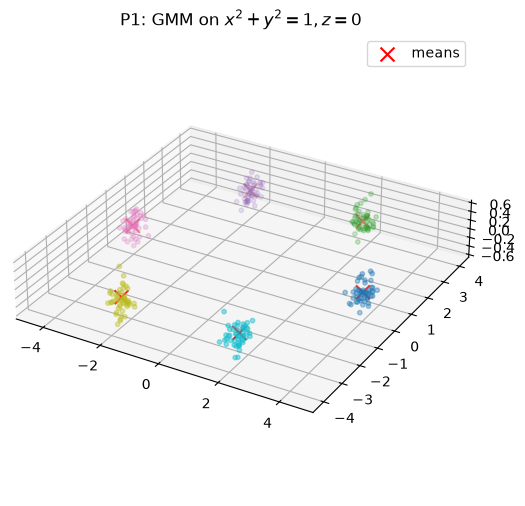

In [2]:
# ----------------------------
# パラメータ
# ----------------------------
K = 6                 # 成分数
N = 300               # 総サンプル数
sigma = 0.2          # 分散スケール

# ----------------------------
# 円周上の6等分点（平均）
# ----------------------------
radius = 4  # 半径を3に変更
theta = np.linspace(0, 2*np.pi, K, endpoint=False)
means = np.stack([
    radius * np.cos(theta),
    radius * np.sin(theta),
    np.zeros(K)
], axis=1)   # shape (6,3)

# ----------------------------
# 共分散（全成分共通）
# ----------------------------
Sigma = sigma**2 * np.eye(3)

# ----------------------------
# GMMからサンプリング
# ----------------------------
points = []
labels = []

for k in range(K):
    Nk = N // K
    samples = np.random.multivariate_normal(
        mean=means[k],
        cov=Sigma,
        size=Nk
    )
    points.append(samples)
    labels.append(np.full(Nk, k))

P_1 = np.vstack(points)
labels = np.concatenate(labels)

# ----------------------------
# 可視化
# ----------------------------
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    P_1[:,0], P_1[:,1], P_1[:,2],
    c=labels, cmap="tab10", s=10, alpha=0.7
)

ax.scatter(
    means[:,0], means[:,1], means[:,2],
    c="red", s=100, marker="x", label="means"
)

ax.set_title("P1: GMM on $x^2+y^2=1, z=0$")
ax.set_box_aspect([1,1,0.2])
ax.legend()
plt.show()


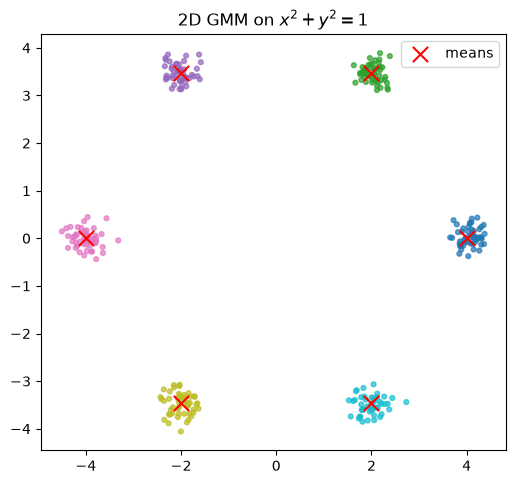

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# パラメータ
# ----------------------------
K = 6
N = 300
sigma = 0.2

# ----------------------------
# 円周上6等分点（平均）
# ----------------------------
theta = np.linspace(0, 2*np.pi, K, endpoint=False)
means_2d = np.stack([
    radius*np.cos(theta),
    radius*np.sin(theta)
], axis=1)   # (6,2)

# ----------------------------
# 共分散（共通）
# ----------------------------
Sigma_2d = sigma**2 * np.eye(2)

# ----------------------------
# サンプリング
# ----------------------------
points_2d = []
labels_2d = []

for k in range(K):
    Nk = N // K
    samples = np.random.multivariate_normal(
        mean=means_2d[k],
        cov=Sigma_2d,
        size=Nk
    )
    points_2d.append(samples)
    labels_2d.append(np.full(Nk, k))

P1_2d = np.vstack(points_2d)
labels_2d = np.concatenate(labels_2d)

# ----------------------------
# 可視化
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(
    P1_2d[:,0], P1_2d[:,1],
    c=labels_2d, cmap="tab10", s=12, alpha=0.7
)
plt.scatter(
    means_2d[:,0], means_2d[:,1],
    c="red", s=120, marker="x", label="means"
)
plt.gca().set_aspect("equal")
plt.title("2D GMM on $x^2 + y^2 = 1$")
plt.legend()
plt.show()


In [4]:
P1_3d = np.hstack([
    P1_2d,
    np.zeros((P1_2d.shape[0], 1))
])
# --- means_2d が既にある前提 ---
means_3d = np.hstack([
    means_2d,
    np.zeros((means_2d.shape[0], 1))
])


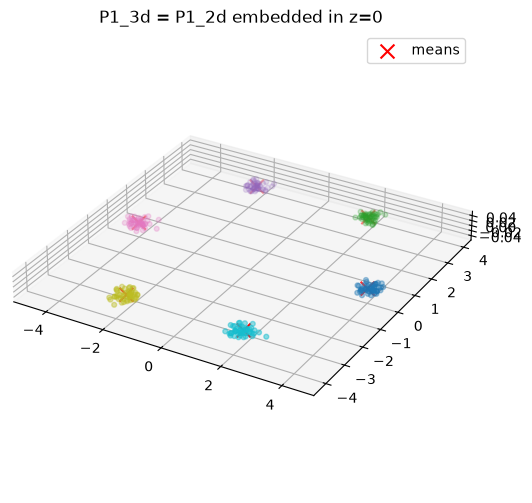

In [5]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    P1_3d[:,0], P1_3d[:,1], P1_3d[:,2],
    c=labels_2d, cmap="tab10", s=12, alpha=0.7
)

ax.scatter(
    means_3d[:,0], means_3d[:,1], means_3d[:,2],
    c="red", s=100, marker="x", label="means"
)

ax.set_title("P1_3d = P1_2d embedded in z=0")
ax.set_box_aspect([1,1,0.1])
ax.legend()
plt.show()


In [6]:
n_noise = 10
noise_center = np.array([2.5*radius, 0.0, 10.0])
noise_radius = 0.3

u = np.random.normal(size=(n_noise, 3))
u /= np.linalg.norm(u, axis=1, keepdims=True)
r_rand = noise_radius * np.random.uniform(0, 1, n_noise) ** (1/3)

P3 = noise_center + u * r_rand[:, None]

In [7]:

P2=P_1 + (0,0,10)

P1= P2[:, :2]

P1_3d = np.hstack([
    P1,
    np.zeros((P1_2d.shape[0], 1))
])

P1=2.5*P1_3d



P23 = 2*np.vstack([P2, P3]) + (0,0,5)

In [8]:
def set_equal_3d_axes(ax, points, margin=0.1):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    center = 0.5 * (mins + maxs)
    radius = 0.5 * (maxs - mins).max()
    radius *= (1 + margin)

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

    ax.set_box_aspect([1, 1, 1])


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


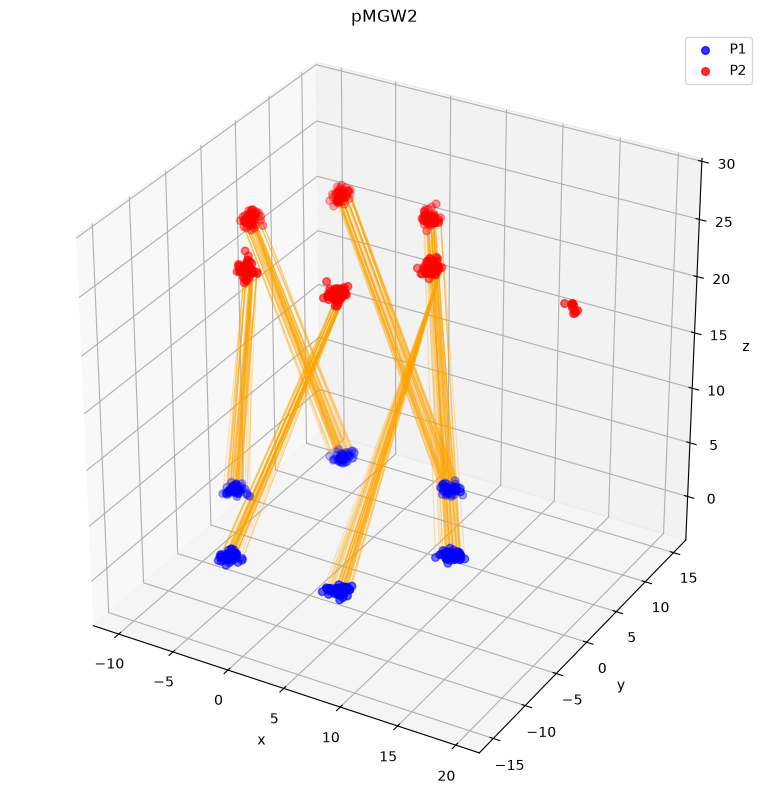

CPU times: user 944 ms, sys: 0 ns, total: 944 ms
Wall time: 944 ms


In [9]:
%%time
import numpy as np
import matplotlib.pyplot as plt
idx = pMGW2_coup(
    X=P1, Y=P23,
    Lambda=0.10,
    n_components_X=6,
    n_components_Y=7,
    solver_tol=1e-12,
    points = True
)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idx = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idx:
    j = idx[i]
    ax.plot(
        [P1[i,0], P23[j,0]],
        [P1[i,1], P23[j,1]],
        [P1[i,2], P23[j,2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("pMGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pmgw_coupling.eps", format="eps", dpi=500)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


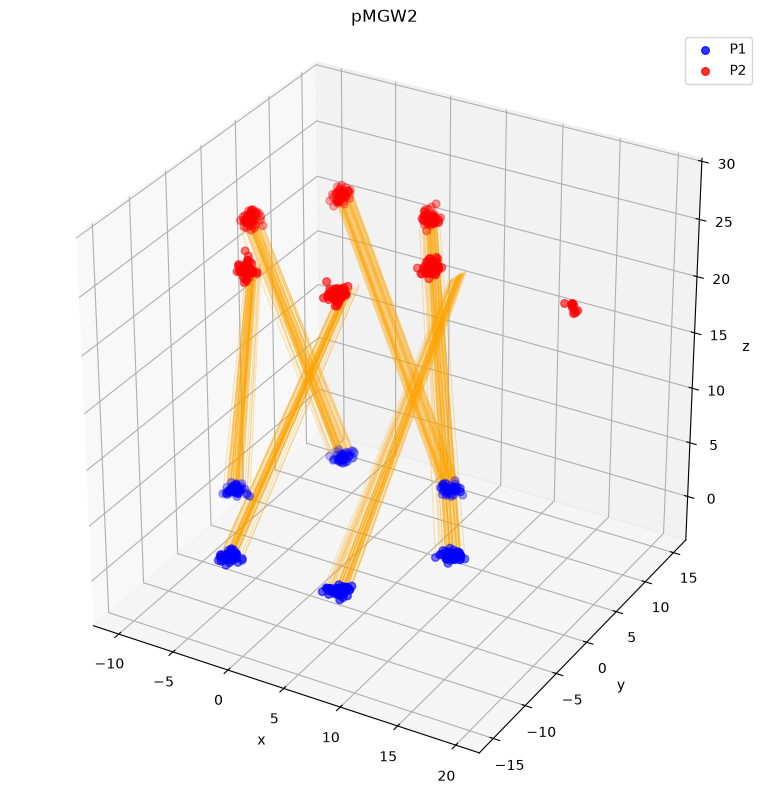

CPU times: user 1.2 s, sys: 41 ms, total: 1.25 s
Wall time: 1.21 s


In [10]:
%%time
import numpy as np
import matplotlib.pyplot as plt
idx = pMGW2_coup(
    X=P1, Y=P23,
    Lambda=0.10,
    n_components_X=6,
    n_components_Y=7,
    solver_tol=1e-12,
    points = False # 重心射影の点を返すように変更
)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idx = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idx:
    mapped_point = idx[i] # idx[i] は直接座標となる
    ax.plot(
        [P1[i,0], mapped_point[0]],
        [P1[i,1], mapped_point[1]],
        [P1[i,2], mapped_point[2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("pMGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pmgw_bary.eps", format="eps", dpi=500)
plt.show()

In [11]:
%%time
import numpy as np
import matplotlib.pyplot as plt
idy = MGW2_coup(X=P1,Y= P23,n_components=6,annealing=False,method='T_mean',points=True,return_both=False,verbose=False)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idy = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idy:
    j = idy[i]
    ax.plot(
        [P1[i,0], P23[j,0]],
        [P1[i,1], P23[j,1]],
        [P1[i,2], P23[j,2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("MGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("mgw_coupling.eps", format="eps", dpi=500)
plt.show()

CPU times: user 15 μs, sys: 1 μs, total: 16 μs
Wall time: 16.9 μs


NameError: name 'MGW2_coup' is not defined

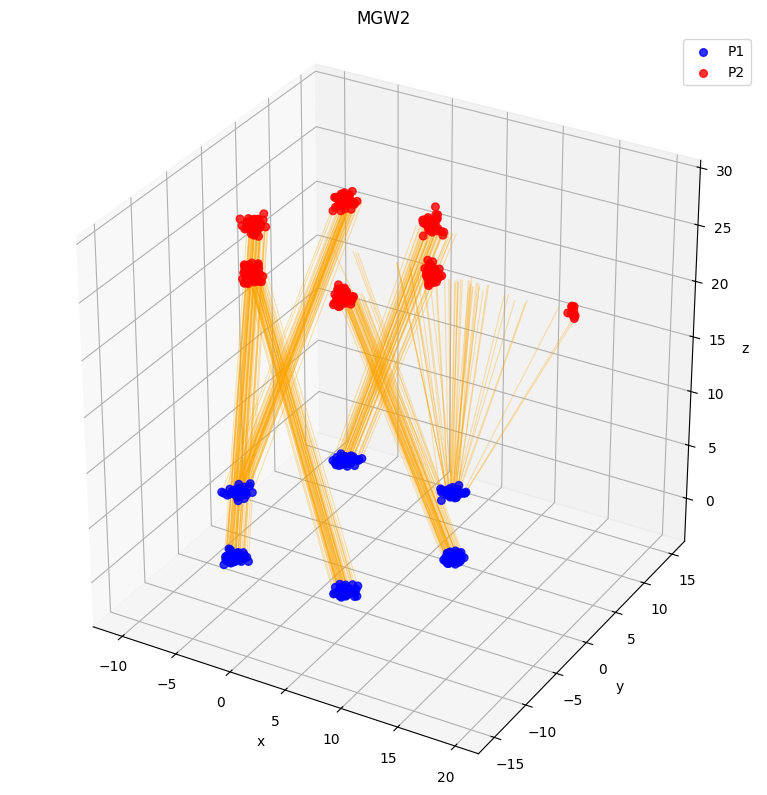

CPU times: user 3.33 s, sys: 17.1 ms, total: 3.35 s
Wall time: 4.43 s


In [ ]:
%%time
import numpy as np
import matplotlib.pyplot as plt
bidy = MGW2_coup(X=P1,Y= P23,n_components=6,annealing=False,method='T_mean',points=False,return_both=False,verbose=False)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idy = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idy:
    mapped_point = bidy[i] # bidy[i] は直接座標となる
    ax.plot(
        [P1[i,0], mapped_point[0]], # P23[j,0] ではなく mapped_point[0] を使用
        [P1[i,1], mapped_point[1]], # P23[j,1] ではなく mapped_point[1] を使用
        [P1[i,2], mapped_point[2]], # P23[j,2] ではなく mapped_point[2] を使用
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("MGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("mgw_bary.eps", format="eps", dpi=500)
plt.show()

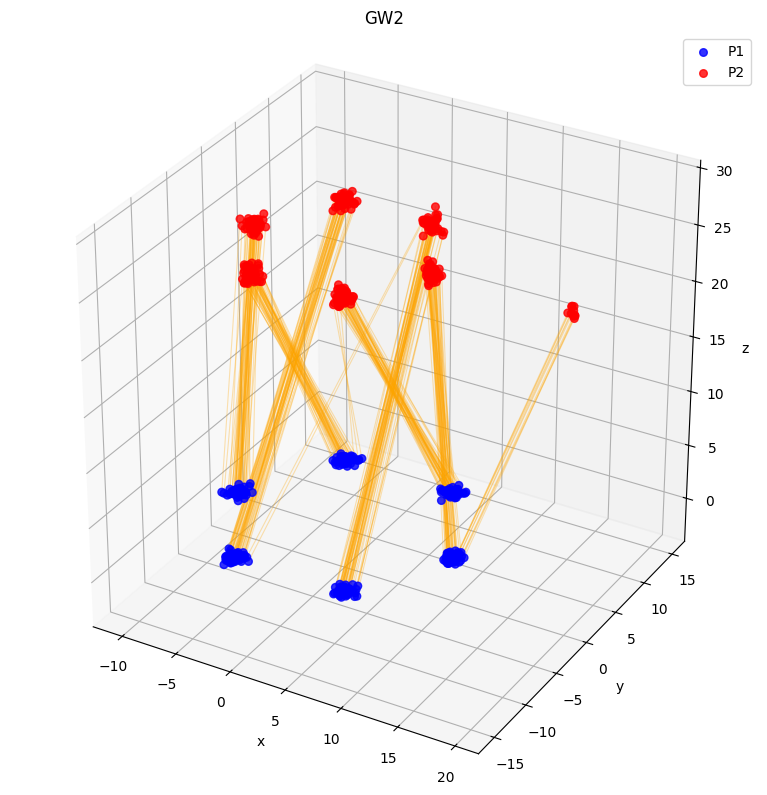

CPU times: user 2.55 s, sys: 18.2 ms, total: 2.57 s
Wall time: 3.22 s


In [ ]:
%%time
import ot
import numpy as np
import matplotlib.pyplot as plt

# 1. 距離行列の計算
C1 = ot.dist(P1, P1)
C23 = ot.dist(P23, P23)

M1 = np.max(C1)
M2 = np.max(C23)
M = np.max([M1,M2])
C1 = C1/M
C23 = C23/M

# 2. 重みの設定（一様分布）
p = ot.unif(len(P1))
q = ot.unif(len(P23))

# 3. Gromov-Wasserstein 輸送行列の計算
# P1 と P23 の相対的な位置関係のみに基づいてマッチング
G = ot.gromov_wasserstein(C1, C23, p, q, 'square_loss', epsilon=5e-3)

# --- 可視化 ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 全点群を結合して軸の範囲を決定するために使用
all_points = np.vstack([P1, P23])

# 点群の描画
ax.scatter(P1[:, 0], P1[:, 1], P1[:, 2], color='blue', label='P1', s=30, alpha=0.8)
ax.scatter(P23[:, 0], P23[:, 1], P23[:, 2], color='red', label='P2', s=30, alpha=0.8)

# マッチングの線を描画 (輸送確率が高い上位のペアのみ)
# 全て描くと重くなるため、各点から最も確率が高い対応先への線を描画
for i in range(len(P1)):
    j = np.argmax(G[i, :])
    if G[i, j] > 1e-5: # 有意な結合のみ
        ax.plot(
            [P1[i, 0], P23[j, 0]],
            [P1[i, 1], P23[j, 1]],
            [P1[i, 2], P23[j, 2]],
            color='orange', alpha=0.3, linewidth=0.8
        )

# 自作関数でアスペクト比を等しく設定
set_equal_3d_axes(ax, all_points)



ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("GW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("gw_coupling.eps", format="eps", dpi=500)
plt.show()


It.  |Err         |Loss        
-------------------------------
    0|4.588262e-02|2.065757e-02


/content/PGW_Metric/lib/gromov.py:790: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwloss` instead.
  print("{:5d}|{:8e}|{:8e}".format(cpt, err, gwloss_partial(C1, C2, G0)))
/usr/local/lib/python3.12/dist-packages/ot/partial/partial_solvers.py:887: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwggrad` instead.
  g = gwgrad_partial(C1, C2, T) * 0.5


Calculation time: 0.426331 sec
Total transported mass: 0.9677


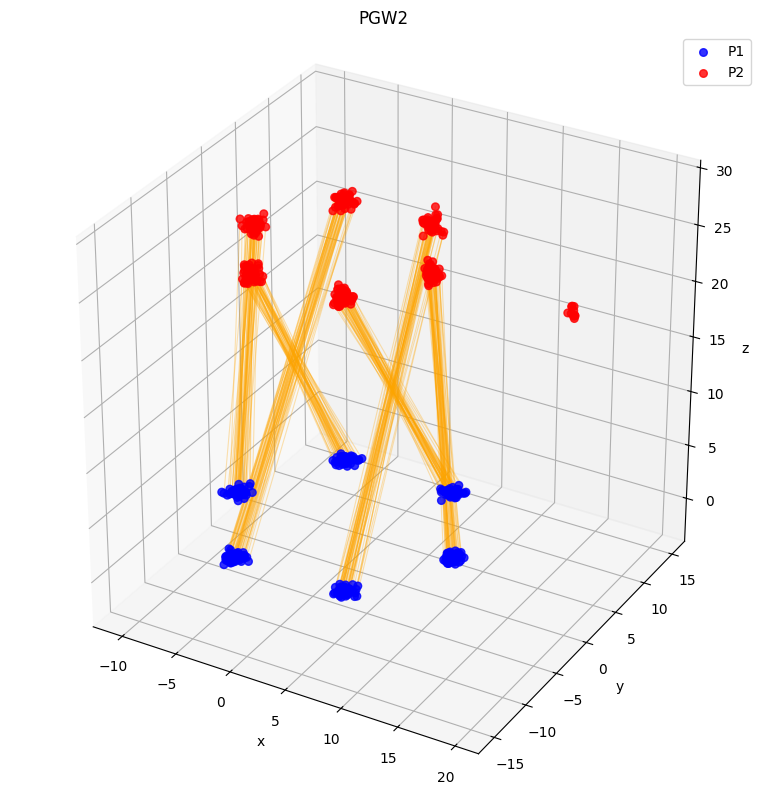

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# --- 前提: 記憶したコードから必要な関数をインポート/定義済みとする ---
# ここでは partial_gromov_ver2 (あるいは ver1) を使う想定です
# Lambda は部分輸送のペナルティ項として機能します

## データの準備 (例として P1 と P23 を定義)
# P1: ソース点群, P23: ターゲット点群 (P23の方が点数が多い、または一部のみ対応する想定)
n1, n2 = len(P1), len(P23)
C1 = ot.dist(P1, P1)
C23 = ot.dist(P23, P23)
M1 = np.max(C1)
M2 = np.max(C23)
M = np.max([M1,M2])
C1 = C1/M
C23 = C23/M

# 重みの設定
p = np.ones(n1) / n1
q = np.ones(n2) / n2

# 輸送したい質量の割合 (例: 全体の 80% だけをマッチングさせる)
# ※ご提示のコードの引数に合わせて調整してください
# m = 0.8 * min(np.sum(p), np.sum(q))

start_time = time.time()

## 3. Partial Gromov-Wasserstein の計算
# 記憶したコードの partial_gromov_ver2 を呼び出し
# Lambda: 輸送されない点へのペナルティ。小さいほど「無理に繋がない」ようになります。
G_partial =  gromov.partial_gromov_ver1(
    C1, C23, p, q,
    Lambda=0.04,       # 距離のスケールに合わせて調整
    numItermax_gw=100,
    verbose=True
)

print(f"Calculation time: {time.time() - start_time:.6f} sec")
print(f"Total transported mass: {np.sum(G_partial):.4f}")

# --- 可視化 ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

all_points = np.vstack([P1, P23])

# 点群の描画
ax.scatter(P1[:, 0], P1[:, 1], P1[:, 2], color='blue', label='P1', s=30, alpha=0.8)
ax.scatter(P23[:, 0], P23[:, 1], P23[:, 2], color='red', label='P2', s=30, alpha=0.8)

# マッチングの線を描画 (Partial GW なので、結合が薄い点は無視される)
# 各ソース点 i について、最も結合が強いターゲット点 j を探す
for i in range(len(P1)):
    j = np.argmax(G_partial[i, :])
    # 閾値判定: 輸送が非常に低い（マッチングから外された）点は描画しない
    if G_partial[i, j] > (0.1 / n1):
        ax.plot(
            [P1[i, 0], P23[j, 0]],
            [P1[i, 1], P23[j, 1]],
            [P1[i, 2], P23[j, 2]],
            color='orange', alpha=0.3, linewidth=0.8
        )

# アスペクト比の設定
set_equal_3d_axes(ax, all_points)



ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("PGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pgw_coupling.eps", format="eps", dpi=500)
plt.show()